# 3.1 线性回归

本 notebook 按《动手学深度学习》2.0 中文版 **3.1 线性回归**的原始章节顺序整理，使用 PyTorch 复现其中的代码演示。内容为学习笔记式重述，并保留教材中的概念、公式编号、图示位置、小结与全部练习。

官方教材：[3.1 线性回归](https://zh.d2l.ai/chapter_linear-networks/linear-regression.html)

回归用于描述一个或多个自变量与因变量之间的关系。当目标是预测连续数值（如价格、住院时间或商品需求）时，通常属于回归问题；预测离散类别则属于后续介绍的分类问题。

## 3.1.1 线性回归的基本元素

线性回归假设输入 $\mathbf{x}$ 与输出 $y$ 之间近似为线性关系，并允许观测中存在噪声。以房价预测为例：

- **训练集**：用于学习模型的数据集合；
- **样本/数据点**：训练集中的一行记录；
- **标签/目标**：希望预测的量，例如房价；
- **特征/协变量**：用于预测的输入，例如面积和房龄。

若训练集含 $n$ 个样本，第 $i$ 个样本可写为
$\mathbf{x}^{(i)}=[x_1^{(i)},x_2^{(i)}]^\top$，标签为 $y^{(i)}$。

### 3.1.1.1 线性模型

用面积和房龄预测房价时，模型可写为

$$
\mathrm{price}=w_{\mathrm{area}}\cdot\mathrm{area}
+w_{\mathrm{age}}\cdot\mathrm{age}+b. \tag{3.1.1}
$$

$w_{\mathrm{area}}$、$w_{\mathrm{age}}$ 是**权重**，决定各特征的影响；$b$ 是**偏置**（也称偏移量或截距）。带偏置的线性变换严格来说是**仿射变换**。

当输入有 $d$ 个特征时，

$$
\hat y=w_1x_1+\cdots+w_dx_d+b, \tag{3.1.2}
$$

将特征和权重分别写成向量：

$$
\hat y=\mathbf{w}^\top\mathbf{x}+b. \tag{3.1.3}
$$

对含 $n$ 个样本的特征矩阵 $\mathbf{X}\in\mathbb{R}^{n\times d}$，所有预测可一次写成

$$
\hat{\mathbf y}=\mathbf X\mathbf w+b. \tag{3.1.4}
$$

其中标量 $b$ 通过广播加到每个样本。真实数据通常含观测误差，因此标签不会严格落在同一个超平面上。学习开始前还需要确定：如何衡量模型质量，以及如何更新参数。

### 3.1.1.2 损失函数

**损失函数**衡量预测值与真实值的差距。回归中常用平方误差。第 $i$ 个样本的损失为

$$
l^{(i)}(\mathbf w,b)=\frac12\left(\hat y^{(i)}-y^{(i)}\right)^2. \tag{3.1.5}
$$

系数 $\frac12$ 使求导后的表达式更简洁。整个训练集上的平均损失为

$$
L(\mathbf w,b)=\frac1n\sum_{i=1}^{n}l^{(i)}(\mathbf w,b)
=\frac1n\sum_{i=1}^{n}\frac12
\left(\mathbf w^\top\mathbf x^{(i)}+b-y^{(i)}\right)^2. \tag{3.1.6}
$$

训练的目标是找到使经验损失最小的参数：

$$
\mathbf w^*,b^*=\operatorname*{argmin}_{\mathbf w,b}L(\mathbf w,b). \tag{3.1.7}
$$

平方项会对较大的预测误差施加更重的惩罚。

### 3.1.1.3 解析解

线性回归是少数能够直接写出闭式解的机器学习问题。把偏置并入参数（等价于给 $\mathbf X$ 增加一列全 1），最小化 $\|\mathbf y-\mathbf X\mathbf w\|^2$，令梯度为 0 可得

$$
\mathbf w^*=(\mathbf X^\top\mathbf X)^{-1}\mathbf X^\top\mathbf y. \tag{3.1.8}
$$

该式要求相关矩阵可逆。实际计算中通常用线性方程求解器或伪逆pinv，避免显式求逆带来的数值问题。解析解便于数学分析，但许多深度学习模型不存在这样的解。

In [1]:
import torch

# 一个小型数值例子：最后一列 1 用于吸收偏置
X = torch.tensor([[1.0, 2.0], [2.0, 1.0], [3.0, 4.0], [4.0, 3.0]])
y = torch.tensor([[2.0], [5.0], [4.0], [7.0]])
X_aug = torch.cat((X, torch.ones((X.shape[0], 1))), dim=1)

# pinv 对不可逆或病态矩阵也更稳健
w_with_b = torch.linalg.pinv(X_aug) @ y
print("权重与偏置：", w_with_b.squeeze())
print("训练集预测：", (X_aug @ w_with_b).squeeze())

权重与偏置： tensor([ 2.0000, -1.0000,  2.0000])
训练集预测： tensor([2.0000, 5.0000, 4.0000, 7.0000])


### 3.1.1.4 随机梯度下降

多数模型没有解析解，因此本书主要使用**梯度下降**：沿损失下降最快的方向反复更新参数。每次遍历全部数据成本很高，所以通常随机抽取一个小批量 $\mathcal B$，计算其平均梯度：

$$
(\mathbf w,b)\leftarrow(\mathbf w,b)
-\frac{\eta}{|\mathcal B|}\sum_{i\in\mathcal B}
\partial_{(\mathbf w,b)}l^{(i)}(\mathbf w,b). \tag{3.1.9}
$$

对于线性模型和平方损失，更新可展开为

$$
\begin{aligned}
\mathbf w &\leftarrow \mathbf w-\frac{\eta}{|\mathcal B|}
\sum_{i\in\mathcal B}\mathbf x^{(i)}
\left(\mathbf w^\top\mathbf x^{(i)}+b-y^{(i)}\right),\\
b &\leftarrow b-\frac{\eta}{|\mathcal B|}
\sum_{i\in\mathcal B}
\left(\mathbf w^\top\mathbf x^{(i)}+b-y^{(i)}\right).
\end{aligned}\tag{3.1.10}
$$

算法先初始化参数，再反复抽取小批量并沿负梯度方向更新。$\eta$ 是**学习率**，$|\mathcal B|$ 是**批量大小**；它们不由训练直接学得，属于**超参数**。超参数通常借助独立验证集调节。

有限次迭代得到的是估计值 $\hat{\mathbf w},\hat b$，不一定精确到达最小点。比训练损失更重要的是模型在未见数据上的表现，即**泛化**能力。

### 3.1.1.5 用模型进行预测

学得 $\hat{\mathbf w}$ 和 $\hat b$ 后，对新输入 $\mathbf x$ 计算
$\hat{\mathbf w}^\top\mathbf x+\hat b$，即可估计目标值。这个过程称为**预测**，深度学习中也常称为**推断**。

本书倾向使用“预测”：统计学中的“推断”通常指根据数据估计参数，两种语境的含义并不完全相同。

## 3.1.2 矢量化加速

训练时需要同时处理小批量样本。把逐元素循环改写为张量运算，既能调用经过优化的线性代数库，又能让表达更简洁并减少手写代码错误。下面比较 10,000 维向量相加的两种方式。

尽量写成矩阵或者张量相加的形式，而非for循环，这时候用的是pytorch底层优化的cpp或者c语言，可以更加高效率

In [2]:
import time

n = 10_000
a = torch.ones(n)
b = torch.ones(n)

c = torch.zeros(n)
start = time.perf_counter()
for i in range(n):
    c[i] = a[i] + b[i]
loop_seconds = time.perf_counter() - start

start = time.perf_counter()
d = a + b
vector_seconds = time.perf_counter() - start

print(f"Python 循环：{loop_seconds:.6f} 秒")
print(f"矢量化运算：{vector_seconds:.6f} 秒")
print("结果一致：", torch.equal(c, d))

Python 循环：0.193929 秒
矢量化运算：0.000133 秒
结果一致： True


通常矢量化运算会快若干数量级。实际耗时受硬件、PyTorch 版本和首次运行开销影响，因此应关注量级而不是某个固定数字。

## 3.1.3 正态分布与平方损失

平方损失可以从噪声的概率模型中得到解释。若随机变量 $x$ 服从均值为 $\mu$、方差为 $\sigma^2$ 的正态分布，其密度为

$$
p(x)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{1}{2\sigma^2}(x-\mu)^2\right). \tag{3.1.11}
$$

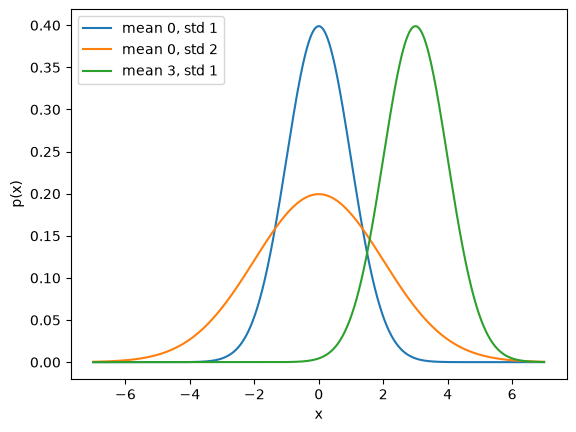

In [3]:
import math
import matplotlib.pyplot as plt

def normal(x, mu, sigma):
    coefficient = 1 / math.sqrt(2 * math.pi * sigma**2)
    return coefficient * torch.exp(-0.5 / sigma**2 * (x - mu)**2)

x = torch.arange(-7.0, 7.0, 0.01)
params = [(0, 1), (0, 2), (3, 1)]

for mu, sigma in params:
    plt.plot(x, normal(x, mu, sigma), label=f"mean {mu}, std {sigma}")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.legend()
plt.show()

改变均值会让曲线沿 $x$ 轴平移；增大标准差会使分布更分散、峰值更低。

在线性回归中，假设观测含有独立的高斯噪声：

$$
y=\mathbf w^\top\mathbf x+b+\epsilon,\qquad
\epsilon\sim\mathcal N(0,\sigma^2). \tag{3.1.12}
$$

给定 $\mathbf x$ 后观察到 $y$ 的条件概率为

$$
P(y\mid\mathbf x)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left[-\frac{1}{2\sigma^2}
\left(y-\mathbf w^\top\mathbf x-b\right)^2\right]. \tag{3.1.13}
$$

若样本相互独立，整个数据集的似然是

$$
P(\mathbf y\mid\mathbf X)
=\prod_{i=1}^{n}p\left(y^{(i)}\mid\mathbf x^{(i)}\right). \tag{3.1.14}
$$

最大化似然等价于最小化负对数似然：

$$
-\log P(\mathbf y\mid\mathbf X)
=\sum_{i=1}^{n}\left[
\frac12\log(2\pi\sigma^2)
+\frac{1}{2\sigma^2}
\left(y^{(i)}-\mathbf w^\top\mathbf x^{(i)}-b\right)^2
\right]. \tag{3.1.15}
$$

当 $\sigma$ 固定时，第一项与参数无关，第二项与平方误差只差常数。因此，在高斯噪声假设下，最小化平方损失等价于线性模型的极大似然估计。

## 3.1.4 从线性回归到深度网络

虽然线性回归是线性模型，我们也可以用神经网络的“层”来描述它，从而把它看成最简单的神经网络。

### 3.1.4.1 神经网络图

![线性回归是一个单层神经网络](https://zh.d2l.ai/_images/singleneuron.svg)

输入为 $x_1,\ldots,x_d$，特征维度为 $d$；输出只有 $o_1$。输入层只提供数据，通常不计入网络层数，所以该模型是一个**单层神经网络**。

每个输入都连接到每个输出，这种变换称为**全连接层**或**稠密层**。图只表达连接关系，并未画出每条边的权重和偏置值。

### 3.1.4.2 生物学

![真实神经元示意图](https://zh.d2l.ai/_images/neuron.svg)

生物神经元通过树突接收输入 $x_i$，突触权重 $w_i$ 调节各输入的影响。加权输入在细胞核附近汇聚成
$y=\sum_i x_iw_i+b$，再经轴突输出，通常还会经过某种非线性处理 $\sigma(y)$。

人工神经元的早期构想受到生物系统启发，但现代深度学习的主要推动力也来自数学、统计学和计算机科学；生物类比有助于直觉理解，却不是对真实神经系统的完整模拟。

## 3.1.5 小结

- 机器学习模型的关键要素包括训练数据、模型、损失函数和优化算法。
- 矢量化让数学表达更简洁，也通常能显著提高运行速度。
- 高斯噪声假设下，最小化平方损失与极大似然估计等价。
- 线性回归可以看作一个单层、全连接的神经网络。

## 3.1.6 练习

以下题目按教材顺序完整保留，建议先独立推导，再展开提示。

### 练习 1

给定 $x_1,\ldots,x_n\in\mathbb R$，寻找常数 $b$ 以最小化
$\sum_i(x_i-b)^2$。

1. 求最优 $b$ 的解析解。
2. 该问题及其解与正态分布有什么关系？

<details>
<summary>提示</summary>

对目标函数关于 $b$ 求导并令其为 0；再把 $b$ 看成固定方差正态分布的均值参数。
</details>

### 练习 2

推导使用平方误差的线性回归解析解。为简化，可忽略偏置 $b$（或向 $\mathbf X$ 添加一列全 1）。

1. 用矩阵和向量写出优化问题。
2. 计算损失关于 $\mathbf w$ 的梯度。
3. 令梯度为 0，解矩阵方程并得到解析解。
4. 解析解何时可能优于随机梯度下降？它又会在什么情况下失效？

<details>
<summary>提示</summary>

从 $\|\mathbf y-\mathbf X\mathbf w\|^2$ 出发；思考维度、矩阵秩、内存需求与数值稳定性。
</details>

### 练习 3

假设附加噪声 $\epsilon$ 服从指数型密度

$$
p(\epsilon)=\frac12\exp(-|\epsilon|).
$$

1. 写出该模型下数据的负对数似然 $-\log P(\mathbf y\mid\mathbf X)$。
2. 尝试写出解析解。
3. 提出随机梯度下降算法。它可能在哪里出问题？尤其考虑参数接近驻点时的行为，并尝试提出解决办法。

<details>
<summary>提示</summary>

负对数似然将导向绝对误差；注意绝对值函数在 0 处不可导，可考虑次梯度、平滑近似或其他稳健优化方法。
</details>

---

本节到此结束。教材接下来的 **3.2 线性回归的从零开始实现** 与 **3.3 线性回归的简洁实现** 属于独立章节，因此没有混入本 notebook。